# Source-integrated CLM shells: matter and galaxy power-ratio checks

This notebook compares the two selectable CLM Fourier implementations in the main source:

- `direct_shell` (the new default): transforms `[M(<r0), diff(M)]` directly with analytic spherical-cell windows;
- `legacy_fftlog`: differentiates the enclosed mass into a nodal density and applies the historical FFTLog plus positive/log interpolation.

Every comparison uses identical cosmology, halo/HOD parameters, and numerical grids. Only the CLM Fourier selector or the static `backreaction` flag changes. The fixed $M(<r)\propto r^2$ continuation is used **only** inside the unresolved CLM cell $[0,r_0]$. It is not used for gas, central stars, or total DMB.


## Quantities plotted

The matter ratio is

$$R_{mm}(k,z)=P_{mm}^{\rm tot}(k,z)/P_{\rm halofit}(k,z).$$

In GODMAX, `Pmm_tot = Pmm_dmb_tot * phfit / Pmm_nfw_tot`, so this is exactly the response-matched hydro/DMO halo-model ratio `Pmm_dmb_tot/Pmm_nfw_tot`. The CLM shell selector must leave it unchanged because DMB still uses the existing real-space density path.

The galaxy ratio is

$$R_{gg}(k,z)=P_{gg}(\mathrm{backreaction=True})/P_{gg}(\mathrm{backreaction=False}),$$

computed separately for each CLM Fourier method. This is the direct large-scale mass-normalization test: $R_{gg}\rightarrow1$ as $k\rightarrow0$.


In [1]:
import copy, sys, time
from pathlib import Path

import jax
jax.config.update('jax_enable_x64', True)  # must precede JAX array creation
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import yaml

ROOT = Path('/mnt/ceph/users/spandey/ltu-godmax/GODMAX')
sys.path.insert(0, str(ROOT / 'src'))
from get_Pkzs import get_Pkz

print('jax', jax.__version__)
print('backend/devices', jax.default_backend(), jax.devices())
print('x64', jax.config.jax_enable_x64, 'default dtype', jnp.asarray(1.0).dtype)


jax 0.5.0
backend/devices cpu [CpuDevice(id=0)]
x64 True default dtype float64


In [2]:
with (ROOT / 'param_files/params_default.yaml').open() as handle:
    DEFAULT = yaml.safe_load(handle)

# A matched validation grid. rmax=48 Mpc/h reduces outer-profile truncation while
# nr=23 intentionally retains the coarse radial resolution under investigation.
# The actual default rmax=8 coverage is diagnosed separately below.
def model_dicts(method, backreaction, *, rmax=48.0, nr=23):
    sim = copy.deepcopy(DEFAULT['sim_params'])
    halo = copy.deepcopy(DEFAULT['halo_params'])
    analysis = copy.deepcopy(DEFAULT['analysis'])
    other = copy.deepcopy(DEFAULT['other_params'])
    halo.update(nz=4, nM=6, nr=nr, nk=64,
                lg10_Mmin=11.5, lg10_Mmax=15.5,
                rmin=0.005, rmax=rmax, kmin=1e-4, kmax=150.0)
    analysis.update(model_tSZ=True, model_galaxies=True,
                    backreaction=backreaction,
                    clm_fourier_transform_method=method,
                    nbar_gal_comoving_val=5e-4,
                    symbolic_hmf=True, symbolic_pk=True,
                    verbose_time=False)
    return sim, halo, analysis, other

def build(method, backreaction, **grid):
    t0 = time.perf_counter()
    obj = get_Pkz(*model_dicts(method, backreaction, **grid))
    print(f'{method:15s} backreaction={backreaction}: {time.perf_counter()-t0:.2f} s')
    return obj

models = {(method, back): build(method, back)
          for method in ('legacy_fftlog', 'direct_shell')
          for back in (False, True)}


legacy_fftlog   backreaction=False: 9.31 s


legacy_fftlog   backreaction=True: 4.78 s


direct_shell    backreaction=False: 4.46 s


direct_shell    backreaction=True: 3.96 s


## Exact isolation and physical diagnostics

A correct CLM Fourier-only change must alter raw `uk_clm` and galaxy-containing spectra, while leaving `Mclm`, `rho_clm`, DMB, halofit, HMF, bias, and HOD arrays exactly unchanged at fixed backreaction. The shell increments are intentionally signed: negative increments are reported, never clipped or silently repaired. Endpoint coverage is checked separately from $u(0)=1$ because normalizing a truncated represented profile does not restore omitted outer mass.


In [3]:
direct = models['direct_shell', True]
legacy = models['legacy_fftlog', True]
null_names = [
    'Mclm_mat', 'rho_clm_mat', 'rho_dmb_mat', 'uk_dmb',
    'Pmm_dmb_tot_mat', 'Pmm_nfw_tot_mat', 'Pmm_tot_mat', 'phfit_kz_mat',
    'hmf_Mz_mat', 'bias_Mz_mat', 'Ncen_mat', 'Nsat_mat',
]
for name in null_names:
    a, b = np.asarray(getattr(direct, name)), np.asarray(getattr(legacy, name))
    print(f'{name:20s} exact={np.array_equal(a, b, equal_nan=True)!s:5s} max|delta|={np.max(np.abs(a-b)):.3e}')

u0 = direct.get_uk_clm_shell(jnp.asarray([0.0]))
dm = direct.get_Mclm_shell_masses(direct.Mclm_mat)
coverage = direct.Mclm_mat[-1] / (direct.fclm_mat * direct.Mtot_mat)
print('direct u(0) max error:', float(jnp.max(jnp.abs(u0 - 1.0))))
print('negative shell count / minimum relative increment:',
      int(jnp.sum(dm[1:] < 0)), float(jnp.min(dm[1:] / direct.Mclm_mat[-1][None])))
print('endpoint/(fclm Mtot) min/median/max:',
      *(float(x) for x in (jnp.min(coverage), jnp.median(coverage), jnp.max(coverage))))

# The repository default rmax=8 Mpc/h is a separate boundary-coverage check.
# It does not enter the plotted matched rmax=48 ratios.
default_box = build('direct_shell', True, rmax=8.0, nr=23)
default_coverage = default_box.Mclm_mat[-1] / (default_box.fclm_mat * default_box.Mtot_mat)
default_dm = default_box.get_Mclm_shell_masses(default_box.Mclm_mat)
print('DEFAULT rmax=8 endpoint/(fclm Mtot) min/median/max:',
      *(float(x) for x in (jnp.min(default_coverage), jnp.median(default_coverage), jnp.max(default_coverage))))
print('DEFAULT rmax=8 negative shells:', int(jnp.sum(default_dm[1:] < 0)))


Mclm_mat             exact=True  max|delta|=0.000e+00
rho_clm_mat          exact=True  max|delta|=0.000e+00
rho_dmb_mat          exact=True  max|delta|=0.000e+00
uk_dmb               exact=True  max|delta|=0.000e+00
Pmm_dmb_tot_mat      exact=True  max|delta|=0.000e+00
Pmm_nfw_tot_mat      exact=True  max|delta|=0.000e+00
Pmm_tot_mat          exact=True  max|delta|=0.000e+00
phfit_kz_mat         exact=True  max|delta|=0.000e+00
hmf_Mz_mat           exact=True  max|delta|=0.000e+00
bias_Mz_mat          exact=True  max|delta|=0.000e+00
Ncen_mat             exact=True  max|delta|=0.000e+00
Nsat_mat             exact=True  max|delta|=0.000e+00


direct u(0) max error: 0.0
negative shell count / minimum relative increment: 10 -6.672790028367006e-07
endpoint/(fclm Mtot) min/median/max: 1.0069382162882798 1.0085535409091122 1.0103014156178698


direct_shell    backreaction=True: 4.28 s
DEFAULT rmax=8 endpoint/(fclm Mtot) min/median/max: 0.7778099814069483 1.0063493928405087 1.0083584363156417
DEFAULT rmax=8 negative shells: 0


In [4]:
ratios = {}
for method in ('legacy_fftlog', 'direct_shell'):
    hydro, no_back = models[method, True], models[method, False]
    ratios[method, 'mm'] = hydro.Pmm_tot_mat / hydro.phfit_kz_mat
    ratios[method, 'gg'] = hydro.Pgg_tot_mat / no_back.Pgg_tot_mat
    ratios[method, 'gg2h'] = hydro.Pgg_2h_kz_mat / no_back.Pgg_2h_kz_mat

k = np.asarray(direct.kPk_array)
low = k <= 1e-2
for method in ('legacy_fftlog', 'direct_shell'):
    print(method)
    print('  max low-k |Pgg 2h ratio - 1| =', float(jnp.max(jnp.abs(ratios[method, 'gg2h'][low] - 1))))
    print('  max low-k |Pgg total ratio - 1| =', float(jnp.max(jnp.abs(ratios[method, 'gg'][low] - 1))))
print('Pmm hydro/DMO method-null max |direct/legacy - 1| =',
      float(jnp.max(jnp.abs(ratios['direct_shell', 'mm'] / ratios['legacy_fftlog', 'mm'] - 1))))


legacy_fftlog
  max low-k |Pgg 2h ratio - 1| = 0.07023530933543276
  max low-k |Pgg total ratio - 1| = 0.13507324138111831
direct_shell
  max low-k |Pgg 2h ratio - 1| = 1.5496989635988e-07
  max low-k |Pgg total ratio - 1| = 1.5913874662487615e-07
Pmm hydro/DMO method-null max |direct/legacy - 1| = 0.0


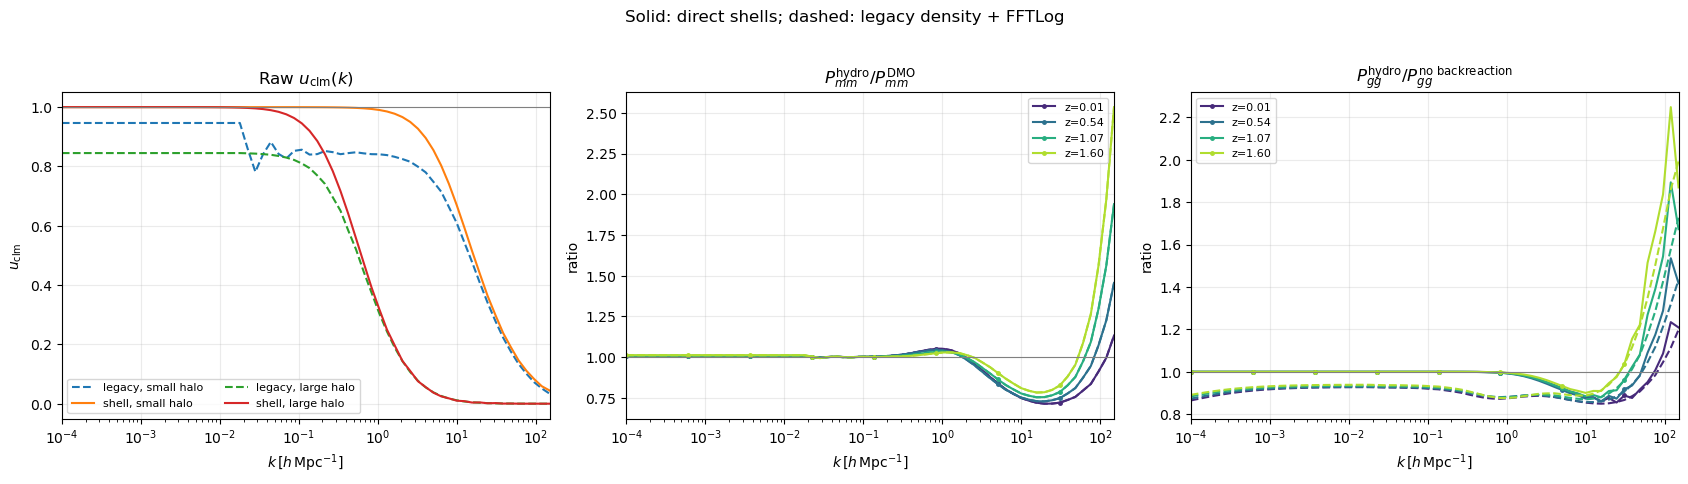

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.7))
colors = plt.cm.viridis(np.linspace(0.12, 0.88, direct.nz))

# Raw CLM windows: show both mass-grid extremes at the lowest redshift.
for im, mass_label in ((0, 'small halo'), (-1, 'large halo')):
    axes[0].semilogx(k, np.asarray(legacy.uk_clm[:, 0, im]),
                     ls='--', label=f'legacy, {mass_label}')
    axes[0].semilogx(k, np.asarray(direct.uk_clm[:, 0, im]),
                     ls='-', label=f'shell, {mass_label}')
axes[0].axhline(1, color='0.5', lw=0.8)
axes[0].set(title=r'Raw $u_{\rm clm}(k)$', xlabel=r'$k\,[h\,\mathrm{Mpc}^{-1}]$', ylabel=r'$u_{\rm clm}$', xlim=(k[0], k[-1]))
axes[0].legend(fontsize=8, ncol=2)
axes[0].grid(alpha=.25)

for iz, color in enumerate(colors):
    z = float(direct.z_array[iz])
    axes[1].semilogx(k, np.asarray(ratios['legacy_fftlog', 'mm'][:, iz]), color=color, ls='--')
    axes[1].semilogx(k, np.asarray(ratios['direct_shell', 'mm'][:, iz]), color=color, ls='-', marker='o', markevery=8, ms=2.5, label=f'z={z:.2f}')
axes[1].axhline(1, color='0.5', lw=.8)
axes[1].set(title=r'$P_{mm}^{\rm hydro}/P_{mm}^{\rm DMO}$', xlabel=r'$k\,[h\,\mathrm{Mpc}^{-1}]$', ylabel='ratio', xlim=(k[0], k[-1]))
axes[1].legend(fontsize=8)
axes[1].grid(alpha=.25)

for iz, color in enumerate(colors):
    z = float(direct.z_array[iz])
    axes[2].semilogx(k, np.asarray(ratios['legacy_fftlog', 'gg'][:, iz]), color=color, ls='--')
    axes[2].semilogx(k, np.asarray(ratios['direct_shell', 'gg'][:, iz]), color=color, ls='-', marker='o', markevery=8, ms=2.5, label=f'z={z:.2f}')
axes[2].axhline(1, color='0.5', lw=.8)
axes[2].set(title=r'$P_{gg}^{\rm hydro}/P_{gg}^{\rm no\ backreaction}$', xlabel=r'$k\,[h\,\mathrm{Mpc}^{-1}]$', ylabel='ratio', xlim=(k[0], k[-1]))
axes[2].legend(fontsize=8)
axes[2].grid(alpha=.25)
fig.suptitle('Solid: direct shells; dashed: legacy density + FFTLog', y=1.02)
fig.tight_layout()
plt.show()


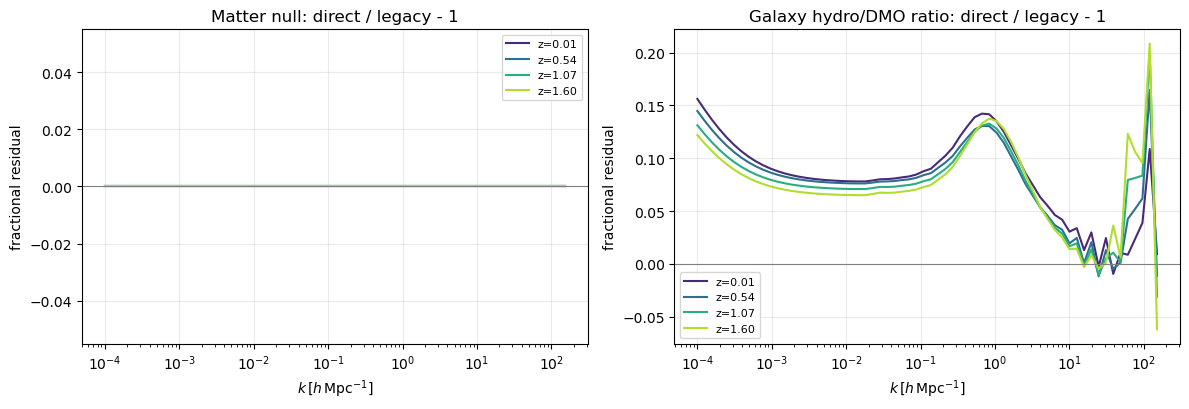

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
mm_method_residual = ratios['direct_shell', 'mm'] / ratios['legacy_fftlog', 'mm'] - 1
gg_method_residual = ratios['direct_shell', 'gg'] / ratios['legacy_fftlog', 'gg'] - 1
for iz, color in enumerate(colors):
    label = f'z={float(direct.z_array[iz]):.2f}'
    axes[0].semilogx(k, np.asarray(mm_method_residual[:, iz]), color=color, label=label)
    axes[1].semilogx(k, np.asarray(gg_method_residual[:, iz]), color=color, label=label)
axes[0].set(title='Matter null: direct / legacy - 1', xlabel=r'$k\,[h\,\mathrm{Mpc}^{-1}]$', ylabel='fractional residual')
axes[1].set(title='Galaxy hydro/DMO ratio: direct / legacy - 1', xlabel=r'$k\,[h\,\mathrm{Mpc}^{-1}]$', ylabel='fractional residual')
for ax in axes:
    ax.axhline(0, color='0.5', lw=.8)
    ax.grid(alpha=.25)
    ax.legend(fontsize=8)
fig.tight_layout()
plt.show()


## Interpretation and limits

1. The direct shell transform is conservative for the **represented cumulative CLM profile**: shell masses telescope to every supplied node and the raw zero mode is exactly one.
2. `Pmm_tot/phfit` must be identical between methods. Any visible separation in the middle panel or nonzero matter residual is a selector leak into DMB and is a failure.
3. The shell `Pgg` ratio approaches one without using the legacy upper clip on raw `uk_clm`. Finite-k differences are physical/numerical shape differences, not a matter-spectrum change.
4. Exact $u(0)=1$ does not prove that the radial box contains the target $f_{clm}M_{tot}$. Inspect endpoint coverage and negative increments before production chains.
5. The p=2 analytic cell is justified by the asymptotic NFW-like CLM cusp. A future shell implementation for total DMB must use separate inner behavior for CLM, central stars, and gas; applying p=2 to DMB would be wrong.
6. The implementation uses only static-shape JAX operations (`diff`, elementary windows, and one `einsum`). CPU/x64 JIT gradients and a short NumPyro NUTS smoke pass, but this host has no visible GPU, so GPU runtime and production-chain throughput remain to be measured.
